# 05 - Train baseline model

Small CNN from scratch to establish a performance baseline (NORMAL vs PNEUMONIA).

## 1. Setup and data

In [1]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

REPO = Path.cwd()
dataset_root = REPO / "data" / "raw" / "chest_xray"
if not dataset_root.exists():
    dataset_root = REPO / "data" / "raw"
models_dir = REPO / "models"
models_dir.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15
VAL_SPLIT = 0.15  # 15% of train for validation (we don't use the val folder)

I0000 00:00:1773795959.891696   85613 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773795959.929473   85613 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773795960.933238   85613 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode="nearest",
    validation_split=VAL_SPLIT,
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=VAL_SPLIT)

# Train and val from "train" folder via validation_split; test from "test"
train_ds = train_datagen.flow_from_directory(
    dataset_root / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED,
    subset="training",
)
val_ds = val_datagen.flow_from_directory(
    dataset_root / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    subset="validation",
)
test_ds = val_datagen.flow_from_directory(
    dataset_root / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)
n_train = train_ds.samples
n_pos = int((train_ds.classes == 1).sum())
n_neg = n_train - n_pos
print(f"Train: {n_train} (NORMAL: {n_neg}, PNEUMONIA: {n_pos})")

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train: 4434 (NORMAL: 1140, PNEUMONIA: 3294)


## 2. Class weights (imbalance)

The dataset has more PNEUMONIA than NORMAL; we use `class_weight` to balance the loss.

In [3]:
weight_neg = n_train / (2 * n_neg)
weight_pos = n_train / (2 * n_pos)
class_weight = {0: weight_neg, 1: weight_pos}
print("Class weights:", class_weight)

Class weights: {0: 1.944736842105263, 1: 0.6730418943533698}


## 3. Baseline model (small CNN)

In [4]:
def build_baseline(input_shape=(224, 224, 3)):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

model_baseline = build_baseline()
model_baseline.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)
model_baseline.summary()

/home/emilio/Desktop/TESIS/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773795961.589562   85613 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,825,345 (10.78 MB)

 Trainable params: 2,825,345 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Callbacks and training

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/15


I0000 00:00:1773795962.536733   85613 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 531ms/step - accuracy: 0.7603 - auc: 0.8683 - loss: 0.4547 - val_accuracy: 0.7430 - val_auc: 0.9462 - val_loss: 0.8190 - learning_rate: 0.0010
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 507ms/step - accuracy: 0.8764 - auc: 0.9467 - loss: 0.3002 - val_accuracy: 0.9003 - val_auc: 0.9641 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 70s 504ms/step - accuracy: 0.8859 - auc: 0.9529 - loss: 0.2806 - val_accuracy: 0.7877 - val_auc: 0.9724 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 509ms/step - accuracy: 0.8987 - auc: 0.9606 - loss: 0.2576 - val_accuracy: 0.9054 - val_auc: 0.9825 - val_loss: 0.2435 - learning_rate: 0.0010
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 514ms/step - accuracy: 0.9046 - auc: 0.9664 - loss: 0.2355 - val_accuracy: 0.9271 - val_auc: 0.9803 - val_loss: 0.1966 - learning_rate: 0.0010
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 69s 499ms/step - accuracy: 0.9181 - 

## 5. Training curves

Train vs validation: loss, accuracy, and AUC over epochs.

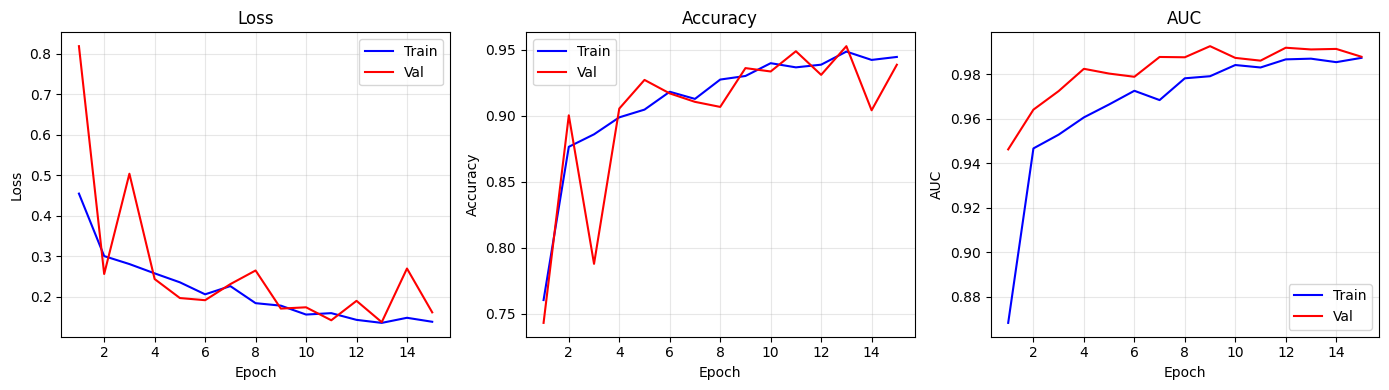

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
epochs = range(1, len(history.history["loss"]) + 1)

# Loss
axes[0].plot(epochs, history.history["loss"], "b-", label="Train")
axes[0].plot(epochs, history.history["val_loss"], "r-", label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history.history["accuracy"], "b-", label="Train")
axes[1].plot(epochs, history.history["val_accuracy"], "r-", label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(epochs, history.history["auc"], "b-", label="Train")
axes[2].plot(epochs, history.history["val_auc"], "r-", label="Val")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_title("AUC")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save baseline model

In [ ]:
path_baseline = models_dir / "baseline.keras"
model_baseline.save(path_baseline)
print(f"Saved: {path_baseline}")
loss, acc, auc = model_baseline.evaluate(test_ds)
print(f"Test — loss: {loss:.4f}, accuracy: {acc:.4f}, AUC: {auc:.4f}")

## 7. Explainability (GradCAM)

GradCAM highlights the regions the model uses to predict **PNEUMONIA**. We expect high activation over lung/opacity areas for pneumonia cases.

In [ ]:
import numpy as np

# Last conv layer (before Flatten) — where we compute the CAM
LAST_CONV_NAME = "conv2d_2"

def make_gradcam_model(model, layer_name):
    """Model that returns (last_conv_output, prediction)."""
    last_conv = model.get_layer(layer_name)
    return keras.Model(inputs=model.input, outputs=[last_conv.output, model.output])

def compute_gradcam(model, img_batch, layer_name=LAST_CONV_NAME):
    """
    Compute GradCAM for the model output (PNEUMONIA prob in binary case).
    Returns CAMs with shape (batch, H, W) in [0, 1], resized to input size.
    """
    img_batch = tf.convert_to_tensor(img_batch)
    # Build model graph if needed (e.g. after loading from .keras) so model.input exists
    try:
        _ = model.input
    except AttributeError:
        _ = model(img_batch[:1])
    grad_model = make_gradcam_model(model, layer_name)
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_batch)
        # Gradient of the (single) output w.r.t. conv features
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_output)
    # Global average of gradients per channel -> weights
    weights = tf.reduce_mean(grads, axis=(1, 2))  # (batch, channels)
    # CAM = ReLU( sum over channels: weight_c * feature_map_c )
    cam = tf.reduce_sum(weights[:, :, np.newaxis, np.newaxis] * conv_output, axis=-1)
    cam = tf.nn.relu(cam)
    # Resize to input size (224, 224)
    cam = tf.image.resize(cam[..., np.newaxis], (IMG_SIZE[0], IMG_SIZE[1]))
    cam = cam.numpy().squeeze(axis=-1)
    # Normalize per image to [0, 1]
    cam = (cam - cam.min(axis=(1, 2), keepdims=True)) / (
        cam.max(axis=(1, 2), keepdims=True) - cam.min(axis=(1, 2), keepdims=True) + 1e-8
    )
    return cam

# Get a few test images: 3 NORMAL + 3 PNEUMONIA
test_ds.reset()
per_class = 3
images_list, labels_list = [], []
for imgs, labels in test_ds:
    for i in range(imgs.shape[0]):
        lab = int(labels[i])
        if lab == 0 and sum(1 for l in labels_list if l == 0) < per_class:
            images_list.append(imgs[i])
            labels_list.append(lab)
        elif lab == 1 and sum(1 for l in labels_list if l == 1) < per_class:
            images_list.append(imgs[i])
            labels_list.append(lab)
    if len(images_list) >= 2 * per_class:
        break
num_show = len(images_list)
images_batch = np.stack(images_list)
labels_batch = np.array(labels_list)

# GradCAM: gradient of PNEUMONIA probability w.r.t. last conv layer
cams = compute_gradcam(model_baseline, images_batch)
preds = model_baseline.predict(images_batch, verbose=0)
preds = preds.flatten()

class_names = list(train_ds.class_indices.keys())  # ['NORMAL', 'PNEUMONIA']

# Plot: original, heatmap, overlay
fig, axes = plt.subplots(num_show, 3, figsize=(10, 2 * num_show))
for i in range(num_show):
    img = images_batch[i]
    cam = cams[i]
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"True: {class_names[labels_batch[i]]}\nPred: {preds[i]:.2f}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(cam, cmap="jet")
    axes[i, 1].set_title("GradCAM (PNEUMONIA)")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(img)
    axes[i, 2].imshow(cam, cmap="jet", alpha=0.4)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")
plt.suptitle("Baseline: regions used for PNEUMONIA prediction", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()